# Anomaly Detection Exercise Set

**Methods:** Z-score · Modified Z-score (MAD) · KNN  
**Datasets:** `daily_sales.csv`, `product_reference.csv`  
**Ground truth for Exercise 4:** `anomaly_answer_key.csv`

This notebook follows the exercise numbering exactly and includes explanatory comments.

## EXERCISE 1 — Z-SCORE DETECTION

DATA QUALITY CHECK

Daily sales shape:
(2921, 3)

Reference shape:
(4, 2)

First 5 rows:
  product_id       date  sales
0       P001 2023-01-01     56
1       P001 2023-01-02     35
2       P001 2023-01-03     44
3       P001 2023-01-04     45
4       P001 2023-01-05     30

Missing values:
product_id    0
date          0
sales         0
dtype: int64

Duplicate product/date rows:
2

PRODUCT REFERENCE
product_id                  product_name
      P001      Widget A - steady seller
      P002 Widget B - seasonal gift item
      P003   Gadget C - low volume/lumpy
      P004  Gadget D - declining product

QUESTION 1 — Z-SCORE CALCULATION

Mean and standard deviation by product:
            mean_sales    std_sales
product_id                         
P001         62.223594   369.289477
P002        169.043716  3283.732555
P003          1.740385     2.268113
P004         39.155738    19.830894

First 10 observations with Z-score:
product_id       date  sales  mean_sales  std_sales   z_score
 

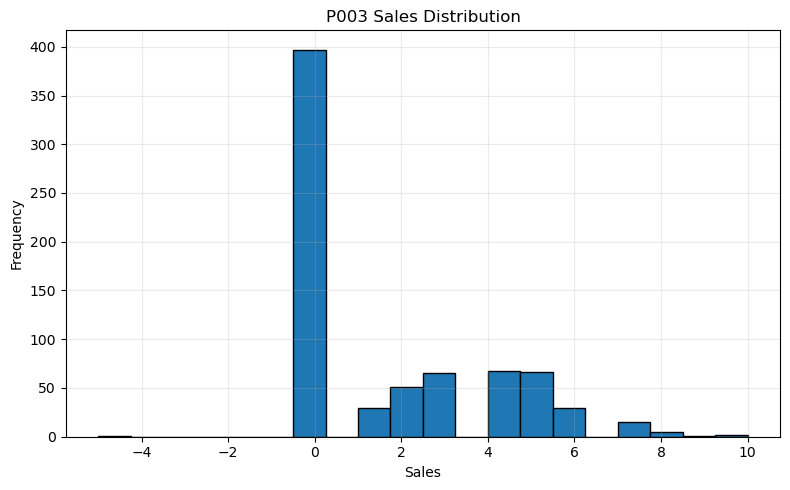


P003 Z-score flagged rows:
      date  sales  z_score
2024-08-14     10 3.641624
2024-11-11      9 3.200729
2024-12-05     10 3.641624

P003 Interpretation:
P003 has many true zero-sales days and a smaller number of positive sales values.
Therefore, the distribution is highly right-skewed and does not resemble a normal symmetric distribution.
Because Z-score uses the mean and standard deviation, its interpretation becomes less reliable for this strongly skewed distribution.
A high sales value may receive a large Z-score even when it represents legitimate lumpy demand rather than a true anomaly.
Therefore, |Z| > 3 flags for P003 should be interpreted carefully rather than automatically treated as real anomalies.

QUESTION 5 — THRESHOLD SENSITIVITY

Threshold sensitivity — detailed results:
 threshold product_id  flagged_count
         2       P001              1
         2       P002              1
         2       P003             24
         2       P004             23
         3    

In [1]:
# ============================================================
# EXERCISE 1 — Z-SCORE ANOMALY DETECTION
# ============================================================
#
# Goal:
#   1. Calculate mean and standard deviation per product
#   2. Calculate Z-score for every observation
#   3. Flag |Z| > 3 as anomaly candidates
#   4. Analyze P002 level shift
#   5. Analyze P003 distribution
#   6. Test threshold sensitivity using |Z| > 2, 3, and 4
#
# Z-score formula:
#       Z = (x - mean) / standard_deviation
#
# ============================================================


# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD DATA
# ============================================================
daily = pd.read_csv("daily_sales.csv")
reference = pd.read_csv("product_reference.csv")


# ============================================================
# BASIC DATA PREPARATION
# ============================================================

# Convert date column from text to datetime
daily["date"] = pd.to_datetime(daily["date"])

# Sort observations by product and date
daily = daily.sort_values(
    ["product_id", "date"]
).reset_index(drop=True)


# ============================================================
# BASIC DATA QUALITY CHECK
# ============================================================
print("=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

print("\nDaily sales shape:")
print(daily.shape)

print("\nReference shape:")
print(reference.shape)

print("\nFirst 5 rows:")
print(daily.head())

print("\nMissing values:")
print(daily.isna().sum())

print("\nDuplicate product/date rows:")
duplicate_count = daily.duplicated(
    ["product_id", "date"]
).sum()

print(duplicate_count)


# ============================================================
# DISPLAY PRODUCT REFERENCE
# ============================================================
print("\n" + "=" * 70)
print("PRODUCT REFERENCE")
print("=" * 70)
print(reference.to_string(index=False))


# ============================================================
# QUESTION 1
# COMPUTE MEAN, STANDARD DEVIATION AND Z-SCORE
# INDEPENDENTLY FOR EACH PRODUCT
# ============================================================
print("\n" + "=" * 70)
print("QUESTION 1 — Z-SCORE CALCULATION")
print("=" * 70)


# Make a copy so that the original daily DataFrame is preserved
z_df = daily.copy()


# ------------------------------------------------------------
# Calculate mean and standard deviation for each product
# ------------------------------------------------------------
product_stats = (z_df.groupby("product_id")["sales"].agg(
        mean_sales="mean",
        std_sales="std"))
print("\nMean and standard deviation by product:")
print(product_stats)


# ------------------------------------------------------------
# Attach product statistics to every observation
# ------------------------------------------------------------
z_df = z_df.join(product_stats,on="product_id")

# ------------------------------------------------------------
# Calculate Z-score
# Formula:Z = (sales - mean) / standard_deviation
# ------------------------------------------------------------
z_df["z_score"] = ((z_df["sales"] - z_df["mean_sales"])/ z_df["std_sales"])
print("\nFirst 10 observations with Z-score:")
print(z_df[[
            "product_id","date","sales",
            "mean_sales","std_sales","z_score"
        ]].head(10).to_string(index=False))

# ============================================================
# QUESTION 2
# FLAG |Z| > 3 AS ANOMALY CANDIDATES
# ============================================================
print("\n" + "=" * 70)
print("QUESTION 2 — Z-SCORE ANOMALY DETECTION")
print("=" * 70)


# ------------------------------------------------------------
# Flag observations whose absolute Z-score is greater than 3
# ------------------------------------------------------------
z_df["z_flag"] = z_df["z_score"].abs() > 3

# ------------------------------------------------------------
# Count anomaly candidates for each product
# ------------------------------------------------------------
z_counts = (z_df.groupby("product_id")["z_flag"].sum().astype(int))
print("\nNumber of Z-score anomaly candidates per product:")
print(z_counts)


# ------------------------------------------------------------
# Display all flagged observations
# ------------------------------------------------------------
z_flagged = (z_df[z_df["z_flag"]]
    [["product_id","date","sales","z_score"]].sort_values(["product_id", "date"]))
print("\nZ-score flagged rows:")
print(z_flagged.to_string(index=False))


# ============================================================
# QUESTION 3
# P002 — GLOBAL VS LOCAL BASELINE
# ============================================================
print("\n" + "=" * 70)
print("QUESTION 3 — P002 GLOBAL VS LOCAL BASELINE")
print("=" * 70)


# ------------------------------------------------------------
# Select P002
# ------------------------------------------------------------
p002 = (daily[daily["product_id"] == "P002"].copy().sort_values("date"))
# ------------------------------------------------------------
# Function to find a candidate level-shift date


def find_candidate_shift_date(group,min_segment_days=90):
    g = (group.sort_values("date").copy())
    # --------------------------------------------------------
    # Remove extreme values temporarily so that one huge
    # outlier does not dominate the change-point search.
    # --------------------------------------------------------
    median = g["sales"].median()
    mad = np.median(np.abs(g["sales"] - median))
    if mad > 0:
        clean = g[(g["sales"] - median).abs()<= 50 * mad].copy()
    else:
        clean = g.copy()


    # Convert sales and dates to NumPy arrays
    x = clean["sales"].to_numpy(dtype=float)
    dates = clean["date"].to_numpy()
    n = len(x)
    # Not enough observations for two large segments
    if n < 2 * min_segment_days:
        return None
    # --------------------------------------------------------
    # Cumulative sums
    # These make the search much faster.
    # --------------------------------------------------------
    csum = np.cumsum(x)
    csum2 = np.cumsum(x ** 2)
    best = None
    # --------------------------------------------------------
    # Test possible change points
    # --------------------------------------------------------
    for i in range(min_segment_days,n - min_segment_days):
        n1 = i
        n2 = n - i
        # Mean before the candidate shift
        mean1 = csum[i - 1] / n1
        # Mean after the candidate shift
        mean2 = (csum[-1] - csum[i - 1]) / n2
        # Sum of squared errors before shift
        sse1 = (csum2[i - 1]- n1 * mean1 ** 2)
        # Sum of squared errors after shift
        sse2 = ((csum2[-1] - csum2[i - 1])- n2 * mean2 ** 2)
        # Total within-segment error
        score = sse1 + sse2
        # Keep the best candidate
        if (
            best is None
            or score < best[0]
        ):
            best = (score,i,mean1,mean2)
    if best is None:
        return None
    return (pd.Timestamp(dates[best[1]]),best[2],best[3])


# ------------------------------------------------------------
# Find candidate shift date
# ------------------------------------------------------------
candidate = find_candidate_shift_date(p002)

P002_SHIFT_DATE = None
# ------------------------------------------------------------
# Use exact ground-truth date if available.
# Otherwise use the candidate date.
# ------------------------------------------------------------
if P002_SHIFT_DATE is not None:
    shift_date = pd.Timestamp(P002_SHIFT_DATE)
    print("\nUsing the supplied P002 shift date:",shift_date.date())
elif candidate is not None:
    shift_date = candidate[0]
    print("\nCandidate P002 shift date:",shift_date.date())
    print("Candidate before-shift mean:",round(candidate[1], 2))
    print("Candidate after-shift mean:",round(candidate[2], 2))
else:
    shift_date = None
    print("\nNo reliable candidate shift date was found.")


# ------------------------------------------------------------
# Calculate global and local statistics
# ------------------------------------------------------------
if shift_date is not None:
    # Before shift
    p002_before = p002[p002["date"] < shift_date]["sales"]
    # After shift
    p002_after = p002[p002["date"] >= shift_date]["sales"]

    # --------------------------------------------------------
    # Global baseline
    # --------------------------------------------------------
    global_mean = p002["sales"].mean()
    global_std = p002["sales"].std()

    # --------------------------------------------------------
    # Local baseline: before shift
    # --------------------------------------------------------
    before_mean = p002_before.mean()
    before_std = p002_before.std()


    # --------------------------------------------------------
    # Local baseline: after shift
    # --------------------------------------------------------
    after_mean = p002_after.mean()
    after_std = p002_after.std()


    # --------------------------------------------------------
    # Display comparison
    # --------------------------------------------------------
    p002_baseline_table = pd.DataFrame({
        "Period": ["Global","Before shift","After shift"],
        "Mean": [global_mean,before_mean,after_mean],
        "Std": [global_std,before_std,after_std]})
    print("\nP002 baseline comparison:")
    print(p002_baseline_table.round(3).to_string(index=False))

    # --------------------------------------------------------
    # Show the first several post-shift observations
    # and calculate their Z-score using the GLOBAL baseline.
    # --------------------------------------------------------
    post_shift = (p002[p002["date"] >= shift_date].copy())
    post_shift["global_z_score"] = ((post_shift["sales"]- global_mean)/ global_std)
    print("\nFirst 10 post-shift observations ""using the GLOBAL baseline:")
    print(post_shift[["date","sales","global_z_score"]].head(10).to_string(index=False))

    # --------------------------------------------------------
    # Interpretation
    # --------------------------------------------------------
    print("\nP002 Interpretation:")
    print(
        "The post-shift period increases the global mean "
        "and may also increase the global standard deviation.")
    print(
        "As more post-shift observations become part of "
        "the global baseline, ordinary post-shift sales "
        "values become less unusual relative to that baseline.")

    print(
        "Therefore, some early level-shift observations "
        "may have large Z-scores, but later post-shift "
        "observations may receive smaller Z-scores and "
        "may no longer satisfy |Z| > 3.")
    print(
        "This demonstrates a limitation of using one "
        "fixed global mean and standard deviation for "
        "time-dependent data.")

# ============================================================
# QUESTION 4
# P003 — DISTRIBUTIONAL SHAPE
# ============================================================
print("\n" + "=" * 70)
print("QUESTION 4 — P003 DISTRIBUTIONAL SHAPE")
print("=" * 70)


# ------------------------------------------------------------
# Select P003 sales
# ------------------------------------------------------------
p003 = daily.loc[daily["product_id"] == "P003","sales"]

# ------------------------------------------------------------
# Statistical summary
# ------------------------------------------------------------
print("\nP003 distribution summary:")
print(p003.describe())

# ------------------------------------------------------------
# Plot P003 sales distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(p003,bins=20,edgecolor="black")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("P003 Sales Distribution")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display P003 Z-score flagged observations
# ------------------------------------------------------------
p003_flagged = z_df[(z_df["product_id"] == "P003")&(z_df["z_flag"])]
print("\nP003 Z-score flagged rows:")
if len(p003_flagged) > 0:
    print(p003_flagged[["date","sales","z_score"]].sort_values("date").to_string(index=False))
else:
    print(
        "No P003 observations were flagged "
        "with |Z| > 3.")

# ------------------------------------------------------------
# P003 interpretation
# ------------------------------------------------------------
print("\nP003 Interpretation:")
print(
    "P003 has many true zero-sales days and a smaller "
    "number of positive sales values.")
print(
    "Therefore, the distribution is highly right-skewed "
    "and does not resemble a normal symmetric distribution.")

print(
    "Because Z-score uses the mean and standard deviation, "
    "its interpretation becomes less reliable for this "
    "strongly skewed distribution.")

print(
    "A high sales value may receive a large Z-score even "
    "when it represents legitimate lumpy demand rather "
    "than a true anomaly.")

print(
    "Therefore, |Z| > 3 flags for P003 should be interpreted "
    "carefully rather than automatically treated as real anomalies.")

# ============================================================
# QUESTION 5
# THRESHOLD SENSITIVITY
# ============================================================
print("\n" + "=" * 70)
print("QUESTION 5 — THRESHOLD SENSITIVITY")
print("=" * 70)


# ------------------------------------------------------------
# Test three thresholds:
# |Z| > 2
# |Z| > 3
# |Z| > 4
# ------------------------------------------------------------

threshold_results = []
for threshold in [2, 3, 4]:
    # Create flag for current threshold
    temp = z_df.assign(flag=(z_df["z_score"].abs()> threshold))
    # Count flags for each product
    counts = (temp.groupby("product_id")["flag"].sum())
    # Store results
    for product, count in counts.items():
        threshold_results.append({
            "threshold": threshold,
            "product_id": product,
            "flagged_count": int(count)})


# ------------------------------------------------------------
# Convert results into DataFrame
# ------------------------------------------------------------
threshold_table = pd.DataFrame(threshold_results)

# ------------------------------------------------------------
# Display long-format results
# ------------------------------------------------------------
print("\nThreshold sensitivity — detailed results:")
print(threshold_table.to_string(index=False))

# ------------------------------------------------------------
# Display easy-to-read comparison table
# ------------------------------------------------------------
threshold_pivot = (threshold_table.pivot(index="product_id",columns="threshold",values="flagged_count")
    .rename(columns={2: "|Z| > 2",3: "|Z| > 3",4: "|Z| > 4"}))
print("\nThreshold sensitivity — comparison:")
print(threshold_pivot.to_string())

# ============================================================
# CALCULATE HOW MUCH THE FLAGGED COUNT CHANGES
# ============================================================
sensitivity_change = pd.DataFrame({
    "Z>2_to_Z>3_change":
        threshold_pivot["|Z| > 2"]- threshold_pivot["|Z| > 3"],
    "Z>3_to_Z>4_change":
        threshold_pivot["|Z| > 3"]- threshold_pivot["|Z| > 4"]})
print("\nChange in number of flagged observations:")
print(sensitivity_change.to_string())


# ============================================================
# FINAL INTERPRETATION OF EXERCISE 1
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 1 — FINAL INTERPRETATION")
print("=" * 70)

print(
    """
1. Z-score measures how far a sales observation is from
   its product-specific mean in units of standard deviation.

2. Using |Z| > 3 identifies observations that are more than
   three standard deviations away from the product mean.

3. P002 demonstrates that a sustained level shift can be
   difficult for a global Z-score detector to identify.
   Once the post-shift period becomes part of the global
   baseline, the mean and standard deviation move toward
   the new sales level.

4. P003 demonstrates the problem with strongly skewed and
   lumpy distributions. Many zero-sales observations are
   legitimate, so a high Z-score does not automatically
   mean that an observation is anomalous.

5. Threshold sensitivity shows that a lower threshold such
   as |Z| > 2 generally produces more anomaly candidates,
   while a higher threshold such as |Z| > 4 produces fewer.
   Therefore, the choice of threshold can have a substantial
   effect on the final anomaly list.

Overall, Z-score is simple and interpretable, but it works
best when the data distribution is reasonably stable and
approximately symmetric. It can struggle with skewed data,
level shifts, and contextual/time-dependent anomalies.
"""
)

## EXERCISE 2 — MODIFIED Z-SCORE (MAD)

In [2]:
# ============================================================
# EXERCISE 2 — MODIFIED Z-SCORE (MAD-BASED) DETECTION
# ============================================================
#
# Goal:
#   1. Calculate median and MAD per product
#   2. Calculate Modified Z-score
#   3. Flag |Modified Z| > 3.5
#   4. Demonstrate robustness using an extreme value
#   5. Compare Z-score and Modified Z-score
#   6. Explain a limitation of both global methods
#
# Formula:
# MAD = median(|x - median|)
# Modified Z-score:
# M = 0.6745 * (x - median) / MAD
# Anomaly condition:
# |M| > 3.5
# ============================================================

# ============================================================
# QUESTION 1
# MEDIAN AND MAD FOR EACH PRODUCT
# ============================================================

print("\n" + "=" * 70)
print("EXERCISE 2 — QUESTION 1")
print("MEDIAN AND MAD")
print("=" * 70)

# Make a copy of the original data
mz_df = daily.copy()

# ------------------------------------------------------------
# Calculate median sales for each product
# ------------------------------------------------------------
median_by_product = (mz_df.groupby("product_id")["sales"].median())
# Add product-specific median to every row
mz_df["median_sales"] = (mz_df["product_id"].map(median_by_product))

# ------------------------------------------------------------
# Calculate absolute deviation from the median
# Absolute deviation:
# |x - median|
# ------------------------------------------------------------
mz_df["absolute_deviation"] = (mz_df["sales"]- mz_df["median_sales"]).abs()

# ------------------------------------------------------------
# Calculate MAD for each product
# MAD = median(|x - median|)
# ------------------------------------------------------------
mad_by_product = (mz_df.groupby("product_id")["absolute_deviation"].median().rename("MAD"))

# Add MAD to every row
mz_df = mz_df.join(mad_by_product,on="product_id")

# ------------------------------------------------------------
# Display median and MAD
# ------------------------------------------------------------
median_mad_table = (mz_df.groupby("product_id").agg(median=("median_sales", "first"),MAD=("MAD", "first")).round(3))
print("\nMedian and MAD by product:")
print(median_mad_table.to_string())

# ============================================================
# QUESTION 2
# CALCULATE MODIFIED Z-SCORE
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 2 — QUESTION 2")
print("MODIFIED Z-SCORE DETECTION")
print("=" * 70)

# ------------------------------------------------------------
# Modified Z-score:
# M = 0.6745 * (x - median) / MAD
# ------------------------------------------------------------

# Start with NaN values
mz_df["modified_z"] = np.nan

# ------------------------------------------------------------
# MAD must be greater than zero.
# If MAD = 0, division by zero would occur.
# Therefore, those rows are left as NaN.
# ------------------------------------------------------------
valid_mad = mz_df["MAD"] > 0
mz_df.loc[valid_mad, "modified_z"] = (0.6745*(
        mz_df.loc[valid_mad, "sales"]-mz_df.loc[valid_mad, "median_sales"])/mz_df.loc[valid_mad, "MAD"])


# ------------------------------------------------------------
# Flag anomalies:
# |Modified Z| > 3.5
# ------------------------------------------------------------
mz_df["mz_flag"] = (mz_df["modified_z"].abs() > 3.5)


# ------------------------------------------------------------
# Count modified Z-score anomalies by product
# ------------------------------------------------------------
modified_z_counts = (mz_df.groupby("product_id")["mz_flag"].sum().astype(int))
print("\nModified Z-score anomaly counts:")
print(modified_z_counts)

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------
modified_z_summary = (mz_df.groupby("product_id").agg(
        median=("median_sales", "first"),
        MAD=("MAD", "first"),
        flagged=("mz_flag", "sum")).round(3))
print("\nModified Z-score summary:")
print(modified_z_summary.to_string())

# ------------------------------------------------------------
# Display flagged observations
# ------------------------------------------------------------
modified_z_flagged = (
    mz_df[mz_df["mz_flag"]]
    [[
            "product_id","date","sales",
            "median_sales","MAD",
            "modified_z"]].sort_values(["product_id", "date"]))
print("\nModified Z-score flagged rows:")
if len(modified_z_flagged) > 0:
    print(modified_z_flagged.to_string(index=False))
else:
    print("No rows were flagged.")

# ------------------------------------------------------------
# Check products with MAD = 0
# ------------------------------------------------------------
zero_mad_products = (median_mad_table[ median_mad_table["MAD"] == 0].index.tolist())
print("\nProducts with MAD = 0:")
if len(zero_mad_products) > 0:
    print(zero_mad_products)
    print(
        "\nFor these products, the standard Modified Z-score "
        "formula is undefined because division by zero would occur.")
else:
    print("None")

# ============================================================
# QUESTION 3
# ROBUSTNESS TEST
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 2 — QUESTION 3")
print("ROBUSTNESS TEST")
print("=" * 70)

# ------------------------------------------------------------
# Function to calculate statistics before and after removing
# one extreme observation.
# ------------------------------------------------------------
def robustness_test(product_id):
    # Select sales for the product
    sales = (daily.loc[daily["product_id"] == product_id,"sales"].astype(float).copy())

    # --------------------------------------------------------
    # First calculate Z-scores using the original data
    # --------------------------------------------------------
    mean_original = sales.mean()
    std_original = sales.std()
    z_values = ((sales - mean_original)/ std_original)

    # --------------------------------------------------------
    # Find the observation with the largest absolute Z-score
    # This directly follows the Exercise 1 results.
    # --------------------------------------------------------
    extreme_idx = z_values.abs().idxmax()
    extreme_value = sales.loc[extreme_idx]

    # --------------------------------------------------------
    # Data WITH extreme observation
    # --------------------------------------------------------
    with_point = sales.copy()

    # --------------------------------------------------------
    # Data WITHOUT extreme observation
    # --------------------------------------------------------
    without_point = sales.drop(index=extreme_idx)
    
    # --------------------------------------------------------
    # Calculate statistics WITH extreme point
    # --------------------------------------------------------
    mean_with = with_point.mean()
    std_with = with_point.std()
    median_with = with_point.median()
    mad_with = np.median(np.abs(with_point - median_with))


    # --------------------------------------------------------
    # Calculate statistics WITHOUT extreme point
    # --------------------------------------------------------
    mean_without = without_point.mean()
    std_without = without_point.std()
    median_without = without_point.median()
    mad_without = np.median(np.abs(without_point - median_without))

    # --------------------------------------------------------
    # Create result table
    # --------------------------------------------------------
    result = pd.DataFrame({
        "Statistic": ["Mean","Standard Deviation","Median","MAD"],
        "With extreme point": [mean_with,std_with,median_with,mad_with],
        "Without extreme point": [mean_without,std_without,median_without,mad_without]})
    
    # Calculate absolute change
    result["Absolute change"] = (result["With extreme point"]-result["Without extreme point"]).abs()
    return (extreme_idx,extreme_value,result)

# ------------------------------------------------------------
# Run robustness test for P001 and P002
# ------------------------------------------------------------
for product in ["P001", "P002"]:
    (extreme_idx,extreme_value,robustness_table) = robustness_test(product)
    print(f"\n{product} — Robustness Test")
    print("Extreme row index:",extreme_idx)
    print("Extreme sales value:",extreme_value)
    print(
        "\nStatistics before and after removing "
        "the extreme point:")
    print(robustness_table.round(4).to_string(index=False))

# ============================================================
# ROBUSTNESS INTERPRETATION
# ============================================================
print("\n" + "-" * 70)
print("ROBUSTNESS INTERPRETATION")
print("-" * 70)
print(
    """
If mean and standard deviation change substantially after
removing one extreme observation, while median and MAD change
very little, this provides numerical evidence that median and
MAD are more robust statistics.

Mean and standard deviation are strongly affected by extreme
values.

Median and MAD are much less affected by extreme values.

Therefore, Modified Z-score is often more reliable than the
ordinary Z-score when the dataset contains strong outliers.
"""
)


# ============================================================
# QUESTION 4
# COMPARE Z-SCORE VS MODIFIED Z-SCORE
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 2 — QUESTION 4")
print("Z-SCORE VS MODIFIED Z-SCORE")
print("=" * 70)


# ------------------------------------------------------------
# Count anomalies detected by each method
# ------------------------------------------------------------
z_counts_comparison = (z_df.groupby("product_id")["z_flag"].sum().rename("Z_score_flags"))
mz_counts_comparison = (mz_df.groupby("product_id")["mz_flag"].sum().rename("Modified_Z_flags"))
comparison = pd.concat([z_counts_comparison,mz_counts_comparison],axis=1).fillna(0).astype(int)
print("\nAnomaly count comparison:")
print(comparison.to_string())

# ------------------------------------------------------------
# Find rows where the two methods disagree
# ------------------------------------------------------------
disagreement = (
    z_df[["product_id","date","sales","z_score","z_flag"]]
    .merge(
        mz_df[["product_id","date","median_sales","MAD","modified_z","mz_flag"]],
        on=["product_id", "date"],
        how="inner"))

# Keep only rows where the methods disagree
disagreement = disagreement[disagreement["z_flag"]!=disagreement["mz_flag"]]

# ------------------------------------------------------------
# Display up to 10 disagreement examples
# ------------------------------------------------------------
print("\nRows where Z-score and Modified Z-score disagree:")
if len(disagreement) > 0:
    print(disagreement[
            ["product_id","date","sales","z_score","median_sales","MAD","modified_z","z_flag","mz_flag"]]
        .sort_values(["product_id", "date"]).head(10).to_string(index=False))

else:
    print("No disagreement rows were found.")

# ============================================================
# AUTOMATICALLY SELECT 3 DISAGREEMENT EXAMPLES
# ============================================================
print("\n" + "-" * 70)
print("THREE DISAGREEMENT EXAMPLES")
print("-" * 70)
examples = disagreement.head(3)
if len(examples) > 0:
    for _, row in examples.iterrows():
        print(f"""
Product: {row['product_id']}
Date: {row['date'].date()}
Sales: {row['sales']}
Z-score: {row['z_score']:.3f}
Median: {row['median_sales']:.3f}
MAD: {row['MAD']:.3f}
Modified Z-score: {row['modified_z']:.3f}
Z-score flagged: {row['z_flag']}
Modified Z-score flagged: {row['mz_flag']}
""" )
else:
    print(
        "There are not enough disagreement rows "
        "to provide examples.")
# ============================================================
# EXPLANATION OF DISAGREEMENT
# ============================================================
print("\n" + "-" * 70)
print("HOW TO INTERPRET DISAGREEMENT")
print("-" * 70)
print(
    """
Z-score measures distance from the MEAN using the STANDARD
DEVIATION.

Modified Z-score measures distance from the MEDIAN using MAD.

The mean and standard deviation can be strongly influenced by
extreme observations. Median and MAD are much more resistant
to extreme observations.

Therefore, the two methods may disagree when an extreme value
changes the mean/std baseline substantially.

For each disagreement row, compare:

1. sales versus mean
2. sales versus median
3. Z-score versus the threshold 3
4. Modified Z-score versus the threshold 3.5

This explains why one method flags the row while the other does not.
"""
)


# ============================================================
# QUESTION 5
# REFLECTION
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 2 — QUESTION 5")
print("REFLECTION")
print("=" * 70)
print(
    """
Anomaly type expected to be difficult for both methods:

SUSTAINED LEVEL SHIFT / GRADUAL DRIFT

Both ordinary Z-score and Modified Z-score compare each
observation against ONE GLOBAL CENTER calculated over the
whole two-year period.

For a level shift, the sales process changes from one level
to another. After enough observations occur at the new level,
the new values become part of the global mean or median.

As a result, the new regime may no longer look unusual.

A gradual drift has the same problem: individual observations
may each be close enough to the global center, even though
the overall process is slowly changing.

Therefore, a fixed-center method is not ideal for detecting
contextual or time-dependent changes.

This is one reason why Exercise 3 introduces KNN with
lag and rolling features.
"""
)


# ============================================================
# FINAL EXERCISE 2 SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 2 — FINAL SUMMARY")
print("=" * 70)

print(
    """
Modified Z-score is a robust alternative to ordinary Z-score.

It uses:

    Median instead of Mean
    MAD instead of Standard Deviation

This makes it less sensitive to extreme observations.

However, Modified Z-score still has an important limitation:
it uses one global median/MAD for the entire time period.

Therefore, it may struggle with:

    - sustained level shifts
    - gradual drift
    - contextual/time-dependent anomalies

These limitations motivate the use of neighborhood-based and
feature-based methods such as KNN in Exercise 3.
""")


EXERCISE 2 — QUESTION 1
MEDIAN AND MAD

Median and MAD by product:
            median   MAD
product_id              
P001          46.0   6.0
P002          40.0  12.0
P003           0.0   0.0
P004          34.0  13.0

EXERCISE 2 — QUESTION 2
MODIFIED Z-SCORE DETECTION

Modified Z-score anomaly counts:
product_id
P001     9
P002    36
P003     0
P004     1
Name: mz_flag, dtype: int64

Modified Z-score summary:
            median   MAD  flagged
product_id                       
P001          46.0   6.0        9
P002          40.0  12.0       36
P003           0.0   0.0        0
P004          34.0  13.0        1

Modified Z-score flagged rows:
product_id       date  sales  median_sales  MAD  modified_z
      P001 2023-03-14    432          46.0  6.0   43.392833
      P001 2023-06-05      0          46.0  6.0   -5.171167
      P001 2023-06-06      0          46.0  6.0   -5.171167
      P001 2023-06-07      0          46.0  6.0   -5.171167
      P001 2023-06-08      0          46.0  6.0   

## EXERCISE 3 — KNN DISTANCE-BASED DETECTION

In [3]:
# ============================================================
# EXERCISE 3 — KNN DISTANCE-BASED ANOMALY DETECTION
# ============================================================
#
# Goal:
# Move from a single global statistic to a method that judges
# each observation by its nearest neighbors.
#
# PART A:
#   1. Univariate KNN using only sales
#   2. k = 5
#   3. Calculate average distance to nearest neighbors
#   4. Flag top 3% anomalies per product
#   5. Compare with Z-score and Modified Z-score
#
# PART B:
#   6. Create contextual/time-series features
#   7. Scale features using StandardScaler
#   8. Apply multivariate KNN
#   9. Flag top 3% anomalies
#  10. Explain contextual anomalies
#  11. Discuss practical trade-offs
#
# ============================================================


# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. LOAD DATA
# ============================================================
print("=" * 70)
print("LOADING DATA")
print("=" * 70)
daily = pd.read_csv("daily_sales.csv")

# Convert date column to datetime
daily["date"] = pd.to_datetime(daily["date"])

# Sort by product and date
daily = (daily.sort_values(["product_id", "date"]).reset_index(drop=True))
print("\nDataset shape:", daily.shape)
print("\nFirst 10 rows:")
print(daily.head(10).to_string(index=False))
print("\nProducts:")
print(daily["product_id"].unique())

# ============================================================
# 2. BASIC DATA QUALITY CHECK
# ============================================================
print("\n" + "=" * 70)
print("BASIC DATA QUALITY CHECK")
print("=" * 70)
print("\nMissing values:")
print(daily.isna().sum())
print("\nDuplicate product/date rows:",daily.duplicated(["product_id", "date"]).sum())


# ============================================================
# IMPORTANT NOTE ABOUT DUPLICATES
# ============================================================
# We DO NOT automatically delete duplicate rows here.
# becuase The exercise specifically says that duplicate_record is astructural anomaly.
# Therefore, deleting duplicates would destroy information
# that we may need later for Exercise 4.We keep them in the original dataset.
# ============================================================

# ============================================================
# PART A — UNIVARIATE KNN
# ============================================================
# Exercise 3 Questions 14–16
# We use ONLY:sales
# For each product separately.
# k = 5
# ============================================================
print("\n" + "=" * 70)
print("PART A — UNIVARIATE KNN")
print("=" * 70)

# ============================================================
# 3. UNIVARIATE KNN FUNCTION
# ============================================================
def univariate_knn_detector(df,k=5,top_fraction=0.03):
    """
    Apply KNN anomaly detection using only the sales feature.

    Parameters
    ----------
    df : pandas DataFrame
        Input sales data.

    k : int
        Number of nearest neighbors.

    top_fraction : float
        Fraction of observations to flag.
        0.03 means top 3%.

    Returns
    -------
    pandas DataFrame
        Original data plus KNN distance and anomaly flag.
    """
    results = []
    # --------------------------------------------------------
    # Analyze each product independently
    # --------------------------------------------------------
    for product_id, g in df.groupby("product_id"):
        # Sort chronologically
        g = (g.sort_values("date").copy())
        # ----------------------------------------------------
        # Use sales as a single feature
        # ----------------------------------------------------
        X = g[["sales"]].to_numpy()

        # ----------------------------------------------------
        # k + 1 because each observation is its own
        # nearest neighbor with distance = 0.
        # We remove the first distance later.
        # ----------------------------------------------------
        model = NearestNeighbors(n_neighbors=k + 1)
        model.fit(X)
        # Find nearest neighbors
        distances, indices = model.kneighbors(X)

        # ----------------------------------------------------
        # Remove self-distance.
        # distances[:, 0] = distance from point to itself = 0
        # Keep the next k distances.
        # ----------------------------------------------------
        neighbor_distances = distances[:, 1:]

        # Calculate average distance to k neighbors
        avg_distance = (neighbor_distances.mean(axis=1))
        g["knn_avg_distance"] = avg_distance

        # ----------------------------------------------------
        # Determine how many observations should be flagged.
        # Example:1000 rows × 3% = 30 anomalies
        # ----------------------------------------------------
        n_flags = max(1,int(np.ceil(len(g) * top_fraction)))

        # ----------------------------------------------------
        # Find observations with largest distances
        # Larger distance = more isolated = more suspicious
        # ----------------------------------------------------
        top_indices = np.argsort(-avg_distance,kind="mergesort")[:n_flags]

        # Initially no observations are flagged
        g["knn_flag"] = False

        # Flag top-distance observations
        g.iloc[top_indices,g.columns.get_loc("knn_flag")] = True
        results.append(g)

    # Combine all products
    return pd.concat(results,ignore_index=True)


# ============================================================
# 4. RUN UNIVARIATE KNN
# ============================================================
knn_uni = univariate_knn_detector(daily,k=5,top_fraction=0.03)

# ============================================================
# 5. UNIVARIATE KNN COUNTS
# ============================================================
print("\nUnivariate KNN flagged counts:")
uni_counts = (knn_uni.groupby("product_id")["knn_flag"].sum().astype(int))
print(uni_counts)

# ============================================================
# 6. DISPLAY UNIVARIATE KNN ANOMALIES
# ============================================================
print("\nTop univariate KNN anomalies:")
uni_flagged = (
    knn_uni[knn_uni["knn_flag"]]
    [["product_id","date","sales","knn_avg_distance"]]
    .sort_values(["product_id","knn_avg_distance"],ascending=[True,False]))
print(uni_flagged.to_string( index=False))


# ============================================================
# QUESTION 16
# COMPARE UNIVARIATE KNN WITH Z-SCORE AND MODIFIED Z-SCORE
# ============================================================
print("\n" + "=" * 70)
print("QUESTION 16 — KNN VS Z-SCORE VS MODIFIED Z-SCORE")
print("=" * 70)

# ============================================================
# 7. CREATE Z-SCORE DATA IF NOT ALREADY AVAILABLE
# ============================================================
if "z_df" not in globals():

    print(
        "\nz_df was not found."
        "\nCreating Z-score results...")
    z_df = daily.copy()
    product_stats = (z_df.groupby("product_id")["sales"].agg(mean_sales="mean",std_sales="std"))
    z_df = z_df.join(product_stats,on="product_id")
    z_df["z_score"] = ((z_df["sales"]-z_df["mean_sales"])/z_df["std_sales"])
    z_df["z_flag"] = (z_df["z_score"].abs() > 3)

# ============================================================
# 8. CREATE MODIFIED Z-SCORE DATA IF NOT AVAILABLE
# ============================================================
if "mz_df" not in globals():
    print(
        "\nmz_df was not found."
        "\nCreating Modified Z-score results...")
    mz_df = daily.copy()

    # Median per product
    median_by_product = (mz_df.groupby("product_id")["sales"].median())
    mz_df["median_sales"] = (mz_df["product_id"].map(median_by_product))

    # Absolute deviation
    mz_df["absolute_deviation"] = (mz_df["sales"]-mz_df["median_sales"]).abs()

    # MAD
    mad_by_product = (mz_df.groupby("product_id")["absolute_deviation"].median().rename("MAD"))
    mz_df = mz_df.join(mad_by_product,on="product_id")
    
    # Initialize
    mz_df["modified_z"] = np.nan
    valid_mad = (mz_df["MAD"] > 0)

    # Modified Z-score
    mz_df.loc[valid_mad,"modified_z"] = (0.6745*(
            mz_df.loc[valid_mad,"sales"]-mz_df.loc[ valid_mad, "median_sales"])/
        mz_df.loc[valid_mad,"MAD"])
    # Flag
    mz_df["mz_flag"] = (mz_df["modified_z"].abs()> 3.5)

# ============================================================
# 9. MERGE ALL THREE METHODS
# ============================================================
comparison_df = (knn_uni[["product_id","date","sales","knn_avg_distance","knn_flag"]]
    .merge(z_df[["product_id","date","z_score","z_flag"]],
        on=["product_id","date"],
        how="left")
    .merge(mz_df[["product_id","date","modified_z","mz_flag"]],
        on=["product_id","date"],
        how="left"))

# ============================================================
# 10. COMPARISON COUNTS
# ============================================================
print("\nAnomaly counts by method:")
method_counts = pd.DataFrame({
    "Z-score": (comparison_df.groupby("product_id")["z_flag"].sum()),
    "Modified Z-score": (comparison_df.groupby("product_id")["mz_flag"].sum()),
    "Univariate KNN": (comparison_df.groupby("product_id")["knn_flag"].sum())})
print(method_counts.astype(int).to_string())

# ============================================================
# 11. FIND DISAGREEMENTS
# ============================================================
disagreements = comparison_df[
    (comparison_df["knn_flag"]!=comparison_df["mz_flag"])|
    (comparison_df["knn_flag"]!=comparison_df["z_flag"])].copy()
print("\nNumber of rows where the methods disagree:",len(disagreements))
print("\nExamples of disagreements:")
print( disagreements[
        ["product_id","date","sales","z_score","modified_z","knn_avg_distance","z_flag","mz_flag","knn_flag"]]
    .sort_values(["product_id","date"]).head(10).to_string(index=False))

# ============================================================
# INTERPRETATION — PART A
# ============================================================
print("\n" + "-" * 70)
print("PART A INTERPRETATION")
print("-" * 70)
print(
    """
Univariate KNN uses only the raw sales value.

Therefore, it can behave similarly to Modified Z-score because
both methods are looking for unusual sales values.
However, they are not identical.
Modified Z-score asks:
    "How far is this observation from the global median?"
KNN asks:
    "How far is this observation from its nearest neighbors?"
Therefore:
    Z-score       -> global mean and standard deviation
    Modified Z    -> global median and MAD
    KNN            -> local neighborhood distances
KNN can detect isolated values even when the global distribution
does not make the value look extremely unusual.
""")

# ============================================================
# PART B — MULTIVARIATE KNN
# ============================================================
# Exercise 3 Questions 17–21
# Features:
#   sales
#   sales_lag_1
#   sales_lag_7
#   rolling_mean_7
#   day_of_week
# ============================================================
print("\n" + "=" * 70)
print("PART B — MULTIVARIATE KNN")
print("=" * 70)

# ============================================================
# 12. FEATURE ENGINEERING FUNCTION
# ============================================================
def build_time_features(df):
    feature_frames = []
    # --------------------------------------------------------
    # Process each product independently
    # --------------------------------------------------------
    for product_id, g in df.groupby("product_id"):
        g = (g.sort_values("date").copy())
        # ----------------------------------------------------
        # Create one sales value per date.
        # If duplicate product/date rows exist, use the meanONLY for feature construction.
        # We do NOT delete duplicates from the original data.
        # ----------------------------------------------------
        daily_series = (g.groupby("date")["sales"].mean().sort_index())

        # ----------------------------------------------------
        # Create complete daily calendar
        # This ensures:
        # lag_1 = previous calendar day
        # lag_7 = previous calendar week
        # ---------------------------------------------------
        calendar = pd.date_range(
            start=daily_series.index.min(),end=daily_series.index.max(),freq="D")

        # Align sales with complete calendar
        s = daily_series.reindex(calendar)

        # Create feature DataFrame
        f = pd.DataFrame(index=calendar)

        # ----------------------------------------------------
        # Previous calendar day's sales
        # ----------------------------------------------------
        f["sales_lag_1"] = (s.shift(1))

        # ----------------------------------------------------
        # Same day previous week
        # ----------------------------------------------------
        f["sales_lag_7"] = (s.shift(7))



        f["rolling_mean_7"] = (s.shift(1).rolling( window=7,min_periods=7).mean())

        # ----------------------------------------------------
        # Day of week
        # Monday = 0
        # Tuesday = 1
        # ...
        # Sunday = 6
        # ---------------------------------------------------
        f["day_of_week"] = (calendar.dayofweek)
        f["product_id"] = (product_id)
        # Convert index into date column
        f = (f.reset_index().rename(columns={"index": "date"}))
        feature_frames.append(f)
    # Combine all products
    feature_table = pd.concat(feature_frames,ignore_index=True)

    # --------------------------------------------------------
    # Merge engineered features back into original data
    # --------------------------------------------------------
    result = df.merge(
        feature_table,
        on=["product_id","date"],
        how="left")
    return result

# ============================================================
# 13. BUILD FEATURES
# ============================================================
multi_df = build_time_features(daily)

# ============================================================
# 14. DEFINE FEATURE COLUMNS
# ============================================================
feature_cols = [
    "sales",
    "sales_lag_1",
    "sales_lag_7",
    "rolling_mean_7",
    "day_of_week"]

# ============================================================
# 15. DISPLAY ENGINEERED FEATURES
# ============================================================
print("\nEngineered features:")
print(
    multi_df[["product_id","date"]+feature_cols]
    .head(15).to_string(index=False))


# ============================================================
# QUESTION 18
# WHY SCALING IS IMPORTANT
# ============================================================
print("\n" + "-" * 70)
print("QUESTION 18 — SCALING")
print("-" * 70)
print(
    """
KNN is a distance-based algorithm.

If the features have different numerical scales, a feature
with a larger numerical range can dominate the distance.

For example, if one feature ranges from 0–1000 and another
ranges from 0–7, the first feature can have much more influence.

StandardScaler transforms the features to comparable scales,
so that each feature can contribute more fairly to the distance.
""")
# ============================================================
# 16. MULTIVARIATE KNN FUNCTION
# ============================================================

def multivariate_knn_detector(df,features,k=5,top_fraction=0.03):
    results = []

    # --------------------------------------------------------
    # Analyze each product separately
    # --------------------------------------------------------
    for product_id, g in df.groupby("product_id"):
        g = g.copy()
        # ----------------------------------------------------
        # Only rows with complete feature values can be used.
        # ----------------------------------------------------
        valid = (g[features].notna().all(axis=1))
        gv = g.loc[valid].copy()
        # If not enough valid rows, skip
        if len(gv) <= k:
            g["knn_avg_distance"] = np.nan
            g["knn_flag"] = False
            results.append(g)
            continue

        # ----------------------------------------------------
        # STANDARDIZE FEATURES
        # ----------------------------------------------------
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform( gv[features])
        # ----------------------------------------------------
        # KNN MODEL
        # k + 1 because each observation is its own neighbor.
        # ----------------------------------------------------

        model = NearestNeighbors(n_neighbors=k + 1)
        model.fit(X_scaled)
        # Find nearest neighbors
        distances, indices = ( model.kneighbors(X_scaled))
        # Remove self-distance
        neighbor_distances = (distances[:, 1:])
        # Average distance
        avg_distance = (neighbor_distances.mean(axis=1))
        gv["knn_avg_distance"] = (avg_distance)
        # ----------------------------------------------------
        # FLAG TOP 3%
        # ----------------------------------------------------
        n_flags = max(1,int(np.ceil(len(gv)*top_fraction)))
        top_indices = np.argsort(-avg_distance,kind="mergesort")[:n_flags]
        gv["knn_flag"] = False
        gv.iloc[top_indices,gv.columns.get_loc("knn_flag" )] = True

        # ----------------------------------------------------
        # Put KNN results back into original product data
        # ----------------------------------------------------
        g["knn_avg_distance"] = np.nan
        g["knn_flag"] = False
        g.loc[gv.index,"knn_avg_distance"] = (gv["knn_avg_distance"])
        g.loc[gv.index,"knn_flag"] = (gv["knn_flag"])
        results.append(g)
    # Combine all products
    return pd.concat(results,ignore_index=True)

# ============================================================
# 17. RUN MULTIVARIATE KNN
# ============================================================
knn_multi = multivariate_knn_detector(multi_df,feature_cols,k=5,top_fraction=0.03)

# ============================================================
# 18. MULTIVARIATE KNN COUNTS
# ============================================================
print("\nMultivariate KNN flagged counts:")
multi_counts = (knn_multi.groupby("product_id")["knn_flag"].sum().astype(int))
print(multi_counts)

# ============================================================
# 19. DISPLAY MULTIVARIATE KNN ANOMALIES
# ============================================================
print("\nTop multivariate KNN anomalies:")
multi_flagged = (
    knn_multi[knn_multi["knn_flag"]]
    [["product_id","date","sales","sales_lag_1","sales_lag_7",
    "rolling_mean_7","day_of_week","knn_avg_distance"]]
    .sort_values(["product_id","knn_avg_distance"],ascending=[True,False]))
print(multi_flagged.to_string(index=False))

# ============================================================
# QUESTION 20
# COMPARE MULTIVARIATE KNN WITH Z-SCORE / MODIFIED Z
# ============================================================
print("\n" + "=" * 70)
print("QUESTION 20 — KEY COMPARISON")
print("=" * 70)


# Merge multivariate KNN with Z-score and Modified Z-score
multi_comparison = (
    knn_multi[[
            "product_id","date","sales","sales_lag_1","sales_lag_7",
            "rolling_mean_7","day_of_week","knn_avg_distance","knn_flag"]]
    .merge(z_df[["product_id","date","z_score","z_flag"]],
        on=["product_id","date"],
        how="left")
    .merge(mz_df[["product_id","date","modified_z","mz_flag"]],
        on=["product_id","date"],
        how="left"))
print("\nMultivariate KNN comparison:")
print(multi_comparison[[
            "product_id","date","sales","z_score","modified_z","knn_avg_distance",
            "z_flag","mz_flag","knn_flag"]]
    .sort_values(["product_id","date"])
    .head(20).to_string(index=False))


# ============================================================
# QUESTION 21
# CONTEXTUAL ANOMALY EXAMPLE
# ============================================================
print("\n" + "=" * 70)
print("QUESTION 21 — CONTEXTUAL ANOMALY")
print("=" * 70)


# Select KNN flagged rows with valid feature values
context_examples = knn_multi[
    (knn_multi["knn_flag"])&(knn_multi["sales_lag_1"].notna())
    &(knn_multi["sales_lag_7"].notna())&(knn_multi["rolling_mean_7"].notna())].copy()
if not context_examples.empty:
    # Highest KNN distance
    example = (context_examples.sort_values( "knn_avg_distance",ascending=False).iloc[0])
    print("\nSelected contextual anomaly example:")
    print(
        example[
            ["product_id","date","sales","sales_lag_1","sales_lag_7",
            "rolling_mean_7","day_of_week","knn_avg_distance"]]
        .to_string() )
    print(
        """ 
Interpretation:

This observation was considered unusual by multivariate KNN
because its complete feature pattern is different from nearby
observations.

The important information comes from:
    sales
    sales_lag_1
    sales_lag_7
    rolling_mean_7
    day_of_week

Z-score and Modified Z-score do not have access to these
contextual features. They only examine the raw sales value
against one global baseline.

Therefore, a value can be normal globally but anomalous in
its local time-series context.
""")
else:
    print("No valid contextual example was available.")

# ============================================================
# QUESTION 22
# PRACTICAL TRADE-OFF
# ============================================================
print("\n" + "=" * 70)
print("QUESTION 22 — PRACTICAL TRADE-OFF")
print("=" * 70)
tradeoff = pd.DataFrame({
    "Method": ["Z-score","Modified Z-score","Multivariate KNN"],
    "Main parameters / choices": [
        "Product grouping + threshold (|Z| > 3)",
        "Product grouping + threshold (|M| > 3.5)",
        "Features + k=5 + StandardScaler + top 3% threshold + distance metric"],
    "Easy to explain?": [
        "Yes — point is unusually high/low compared with the product's global mean.",
        "Yes — point is unusually high/low compared with the product's global median.",
        "Moderately difficult — point is far from its nearest neighbors in a multi-feature space."],
    "If a fifth product is added": [

        "Calculate a new mean/std for the fifth product.",

        "Calculate a new median/MAD for the fifth product.",

        "Run the same feature-engineering, scaling, and KNN pipeline for the fifth product."
    ]})
print(tradeoff.to_string(index=False))


# ============================================================
# PRACTICAL RECOMMENDATION
# ============================================================
print("\n" + "-" * 70)
print("PRACTICAL RECOMMENDATION")
print("-" * 70)
print(
    """
For a live monitoring pipeline:

I would use Modified Z-score as a transparent first-line
detector because it is:

    1. Simple
    2. Computationally inexpensive
    3. Robust to extreme values
    4. Easy to explain to stakeholders

For deeper investigation:

I would use Multivariate KNN as a secondary/offline detector
because it can identify contextual anomalies using:

    - current sales
    - previous-day sales
    - previous-week sales
    - recent 7-day average
    - day of week

However, KNN requires more feature engineering, scaling,
parameter choices, and threshold validation.

Therefore:

    LIVE MONITORING
        -> Modified Z-score

    OFFLINE / DEEP INVESTIGATION
        -> Multivariate KNN
""")


# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 3 — FINAL SUMMARY")
print("=" * 70)

print(
    """
KNN differs from Z-score and Modified Z-score because it does
not depend only on one global center.

UNIVARIATE KNN:
    Uses only sales.
    Looks at local numerical neighbors.

MULTIVARIATE KNN:
    Uses sales + temporal/contextual features.
    Can identify observations that are unusual relative to
    their recent or weekly context.

Z-SCORE:
    Global mean + standard deviation.

MODIFIED Z-SCORE:
    Global median + MAD.

KNN:
    Local neighborhood distance.

This makes multivariate KNN especially useful for contextual
anomalies that may not appear extreme when looking only at the
global sales distribution.
""")


# ============================================================
# OPTIONAL — SAVE RESULTS
# ============================================================
# Save univariate KNN results
knn_uni.to_csv("exercise3_univariate_knn_results.csv",index=False)
# Save multivariate KNN results
knn_multi.to_csv("exercise3_multivariate_knn_results.csv",index=False)
# Save method comparison
comparison_df.to_csv("exercise3_knn_zscore_comparison.csv",index=False)
print("\nResults saved successfully:")
print("1. exercise3_univariate_knn_results.csv")
print("2. exercise3_multivariate_knn_results.csv")
print("3. exercise3_knn_zscore_comparison.csv")
print("\nExercise 3 completed successfully.")

LOADING DATA

Dataset shape: (2921, 3)

First 10 rows:
product_id       date  sales
      P001 2023-01-01     56
      P001 2023-01-02     35
      P001 2023-01-03     44
      P001 2023-01-04     45
      P001 2023-01-05     30
      P001 2023-01-06     34
      P001 2023-01-07     55
      P001 2023-01-08     52
      P001 2023-01-09     40
      P001 2023-01-10     36

Products:
['P001' 'P002' 'P003' 'P004']

BASIC DATA QUALITY CHECK

Missing values:
product_id    0
date          0
sales         0
dtype: int64

Duplicate product/date rows: 2

PART A — UNIVARIATE KNN

Univariate KNN flagged counts:
product_id
P001    22
P002    22
P003    22
P004    22
Name: knn_flag, dtype: int64

Top univariate KNN anomalies:
product_id       date  sales  knn_avg_distance
      P001 2023-08-08   9999            9768.0
      P001 2024-07-02    490             342.6
      P001 2023-03-14    432             296.2
      P001 2023-06-05      0              12.2
      P001 2023-06-06      0              

## EXERCISE 4 — GROUND TRUTH EVALUATION

In [4]:
# ============================================================
# EXERCISE 4 — SCORING ALL THREE METHODS AGAINST GROUND TRUTH
# ============================================================
#
# Methods:
#   1. Z-score
#   2. Modified Z-score (MAD)
#   3. Multivariate KNN
#
# Exercises:
#   23. Load anomaly_answer_key.csv
#   24. Calculate Precision and Recall
#   25. Recall by anomaly type
#   26. Confirm structural anomalies
#   27. Rank methods by Recall and Precision
#
# IMPORTANT:
# This section should be run AFTER Exercises 1–3.
# ============================================================


# ============================================================
# 23. LOAD THE GROUND-TRUTH ANSWER KEY
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 4 — GROUND-TRUTH EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# Load the answer key
# ------------------------------------------------------------
KEY_PATH = "anomaly_answer_key.csv"
try:
    key = pd.read_csv(KEY_PATH)
    print("\n✓ anomaly_answer_key.csv loaded successfully.")
except FileNotFoundError:
    raise FileNotFoundError(
        "\nERROR: anomaly_answer_key.csv was not found.\n"
        "Please place anomaly_answer_key.csv in the same folder "
        "as your notebook and daily_sales.csv.")


# ------------------------------------------------------------
# Display answer-key information
# ------------------------------------------------------------
print("\nGround-truth columns:")
print(list(key.columns))
print("\nGround-truth shape:")
print(key.shape)
print("\nGround-truth preview:")
print(key.head(10).to_string(index=False))

# ============================================================
# IDENTIFY IMPORTANT COLUMNS
# ============================================================

# Different versions of the exercise may use slightly
# different column names.
# This function tries to find the correct column automatically.

def find_column(columns, possible_names):
    column_map = {
        str(column).lower(): column
        for column in columns}
    for name in possible_names:
        if name.lower() in column_map:
            return column_map[name.lower()]
    return None


# ------------------------------------------------------------
# Find product column
# ------------------------------------------------------------
key_product_col = find_column(key.columns,["product_id","product","productid"])

# ------------------------------------------------------------
# Find date column
# ------------------------------------------------------------
key_date_col = find_column(key.columns,["date","anomaly_date","timestamp"])

# ------------------------------------------------------------
# Find anomaly-type column
# ------------------------------------------------------------
key_type_col = find_column( key.columns, ["type","anomaly_type","anomaly"])

# ------------------------------------------------------------
# Check whether required columns were found
# ------------------------------------------------------------
if key_product_col is None:
    raise ValueError(
        "Could not find the product_id column in "
        "anomaly_answer_key.csv.")
if key_date_col is None:
    raise ValueError(
        "Could not find the date column in "
        "anomaly_answer_key.csv.")
if key_type_col is None:
    raise ValueError(
        "Could not find the anomaly type column in "
        "anomaly_answer_key.csv.")
print("\nDetected columns:")
print("Product column :", key_product_col)
print("Date column    :", key_date_col)
print("Type column    :", key_type_col)

# ============================================================
# PREPARE GROUND TRUTH DATA
# ============================================================
key_eval = key.copy()
# Convert dates into pandas datetime format
key_eval["date"] = pd.to_datetime(key_eval[key_date_col])

# Make product IDs consistent
key_eval["product_id"] = (key_eval[key_product_col].astype(str))

# Make anomaly types consistent
key_eval["anomaly_type"] = (key_eval[key_type_col].astype(str).str.strip().str.lower())
print("\nAnomaly types found in answer key:")
print(key_eval["anomaly_type"].value_counts())

# ============================================================
# ANOMALY TYPES
# ============================================================
all_anomaly_types = [
    "point_spike","stockout_zero_run","level_shift_start","data_entry_error",
    "missing_record","duplicate_record","gradual_drift_start"]


# ------------------------------------------------------------
# Structural anomalies
# ------------------------------------------------------------
structural_types = {"missing_record","duplicate_record"}

# ------------------------------------------------------------
# Value anomalies
# ------------------------------------------------------------
value_anomaly_types = [
    "point_spike","stockout_zero_run","level_shift_start",
    "data_entry_error","gradual_drift_start"]

# ============================================================
# 24. PREPARE THE THREE DETECTORS
# ============================================================
# ------------------------------------------------------------
# Z-SCORE
# ------------------------------------------------------------
z_detector = (
    z_df[["product_id","date","z_flag"]]
    .copy().rename(columns={"z_flag": "flag"}))


# ------------------------------------------------------------
# MODIFIED Z-SCORE
# ------------------------------------------------------------
modified_z_detector = (
    mz_df[["product_id","date","mz_flag"]]
    .copy().rename(columns={ "mz_flag": "flag"}))

# ------------------------------------------------------------
# MULTIVARIATE KNN
# ------------------------------------------------------------
knn_detector = (
    knn_multi[["product_id","date","knn_flag"]]
    .copy().rename(columns={"knn_flag": "flag"}))
# ------------------------------------------------------------
# Store all detectors in one dictionary
# ------------------------------------------------------------
detectors = {
    "Z-score":z_detector,
    "Modified Z-score":modified_z_detector,
    "Multivariate KNN":knn_detector}

# ============================================================
# CREATE GROUND-TRUTH SET
# ============================================================
# Structural anomalies are excluded from normal
# value-based precision/recall calculations.
value_truth = key_eval[~key_eval["anomaly_type"].isin(structural_types)].copy()
# ------------------------------------------------------------
# Create (product_id, date) pairs
# ------------------------------------------------------------
truth_pairs = set( zip(value_truth["product_id"].astype(str),value_truth["date"]))
print("\nNumber of value-anomaly ground-truth rows:")
print(len(truth_pairs))

# ============================================================
# FUNCTION TO CALCULATE PRECISION AND RECALL
# ============================================================
def calculate_metrics(detector_df, truth_pairs):
    # --------------------------------------------------------
    # Get predicted anomaly rows
    # -------------------------------------------------------
    predicted = detector_df[detector_df["flag"] == True].copy()

    # --------------------------------------------------------
    # Convert predictions into pairs
    # --------------------------------------------------------
    predicted_pairs = set(zip(predicted["product_id"].astype(str),pd.to_datetime(predicted["date"])))
    # --------------------------------------------------------
    # True Positives
    # --------------------------------------------------------
    TP = len(predicted_pairs.intersection(truth_pairs))
    # -------------------------------------------------------
    # False Positives
    # --------------------------------------------------------
    FP = len(predicted_pairs.difference(truth_pairs))
    # --------------------------------------------------------
    # False Negatives
    # --------------------------------------------------------
    FN = len(truth_pairs.difference(predicted_pairs))
    # --------------------------------------------------------
    # Precision
    # Precision = TP / (TP + FP)
    # --------------------------------------------------------
    if (TP + FP) > 0:
        precision = TP / (TP + FP)
    else:
        precision = 0
    # --------------------------------------------------------
    # Recall
    # Recall = TP / (TP + FN)
    # --------------------------------------------------------
    if (TP + FN) > 0:
        recall = TP / (TP + FN)
    else:
        recall = 0
    return TP, FP, FN, precision, recall
# ============================================================
# CALCULATE OVERALL PRECISION AND RECALL
# ============================================================
evaluation_results = []

for method, detector_df in detectors.items():
    TP, FP, FN, precision, recall = (calculate_metrics(detector_df,truth_pairs))
    evaluation_results.append({
        "Method":method,
        "TP":TP,
        "FP": FP,
        "FN":FN,
        "Precision":precision,
        "Recall":recall})
# ------------------------------------------------------------
# Create evaluation table
# ------------------------------------------------------------
evaluation = pd.DataFrame(evaluation_results)
print("\n" + "=" * 70)
print("EXERCISE 24 — OVERALL PRECISION AND RECALL")
print("=" * 70)
print(evaluation.round(4).to_string(index=False))
# ============================================================
# 25. RECALL BY ANOMALY TYPE
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 25 — RECALL BY ANOMALY TYPE")
print("=" * 70)
recall_results = []
for method, detector_df in detectors.items():
    # --------------------------------------------------------
    # Get predicted rows
    # --------------------------------------------------------
    predicted = detector_df[detector_df["flag"] == True].copy()
    predicted_pairs = set(
        zip(predicted["product_id"].astype(str),pd.to_datetime(predicted["date"])))
    row = {"Method": method}
    # --------------------------------------------------------
    # Calculate recall for every anomaly type
    # --------------------------------------------------------
    for anomaly_type in all_anomaly_types:
        truth_type = key_eval[key_eval["anomaly_type"] == anomaly_type].copy()
        truth_type_pairs = set(
            zip(truth_type["product_id"].astype(str),
                pd.to_datetime(truth_type["date"])))
        # ----------------------------------------------------
        # Structural anomalies
        # ----------------------------------------------------
        if anomaly_type in structural_types:
            # These cannot be detected by ordinary
            # row-based value detectors.
            recall = 0.0
        # ----------------------------------------------------
        # Value anomalies
        # ----------------------------------------------------
        else:
            if len(truth_type_pairs) == 0:
                recall = np.nan
            else:
                TP_type = len(predicted_pairs.intersection(truth_type_pairs))
                recall = (TP_type /len(truth_type_pairs))
        row[anomaly_type] = recall
    recall_results.append(row)


# ------------------------------------------------------------
# Create recall table
# ------------------------------------------------------------
recall_by_type = pd.DataFrame(recall_results)
print( recall_by_type.round(3).to_string(index=False))

# ============================================================
# EXERCISE 26 — STRUCTURAL ANOMALIES
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 26 — STRUCTURAL ANOMALIES")
print("=" * 70)
print(
    """
missing_record and duplicate_record are structural anomalies.

A missing_record cannot receive a Z-score, Modified Z-score,
or KNN score because the row itself does not exist.

A duplicate_record may contain a completely normal sales value,
so it may not look unusual numerically.

Therefore, failure of these three detectors to identify
missing_record and duplicate_record is expected behavior,
not a programming error.
""")

# ============================================================
# CHECK STRUCTURAL ANOMALY RECALL
# ============================================================
print("Structural anomaly recall:")
print(recall_by_type[["Method","missing_record","duplicate_record"]]
    .round(3).to_string(index=False))

# ============================================================
# 27. RANK METHODS BY RECALL
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 27 — RECALL RANKING")
print("=" * 70)

# ------------------------------------------------------------
# Calculate average recall across the five requested
# value-anomaly types.
# ------------------------------------------------------------
recall_ranking = recall_by_type[["Method"] + value_anomaly_types].copy()
recall_ranking["Average_Recall"] = recall_ranking[value_anomaly_types].mean(axis=1)
# ------------------------------------------------------------
# Sort from best to worst
# ------------------------------------------------------------
recall_ranking = (recall_ranking.sort_values("Average_Recall",ascending=False))
print(recall_ranking.round(3).to_string(index=False))
# ============================================================
# PRECISION BY VALUE-ANOMALY TYPES
# ============================================================
# Exercise 27 asks for precision ranking across the
# five important value-anomaly types.
# For each method:
# Precision =correctly flagged value anomalies /all flagged rows associated with these anomaly types
# ------------------------------------------------------------
# Ground truth for the five target anomaly types
target_truth = key_eval[key_eval["anomaly_type"].isin(value_anomaly_types)].copy()
target_truth_pairs = set(zip(target_truth["product_id"].astype(str),target_truth["date"]))
precision_results = []
for method, detector_df in detectors.items():
    predicted = detector_df[detector_df["flag"] == True].copy()
    predicted_pairs = set(
        zip(predicted["product_id"].astype(str),pd.to_datetime(predicted["date"])))
    # --------------------------------------------------------
    # True positives
    # --------------------------------------------------------
    TP = len(predicted_pairs.intersection(target_truth_pairs))
    # --------------------------------------------------------
    # False positives
    # --------------------------------------------------------
    FP = len(predicted_pairs.difference(target_truth_pairs))
    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------
    if (TP + FP) > 0:
        precision = TP / (TP + FP)
    else:
        precision = 0
    precision_results.append({
        "Method":method,
        "TP":TP,
        "FP":FP,
        "Precision":precision})
# ------------------------------------------------------------
# Create precision ranking table
# ------------------------------------------------------------
precision_ranking = pd.DataFrame(precision_results)
precision_ranking = (precision_ranking.sort_values("Precision",ascending=False))
print(precision_ranking.round(4).to_string(index=False))
# ============================================================
# FINAL RANKINGS
# ============================================================
print("\n" + "=" * 70)
print("FINAL METHOD RANKINGS")
print("=" * 70)
# ------------------------------------------------------------
# Recall ranking
# ------------------------------------------------------------
print("\n1. RECALL — Best to Worst")
for rank, (_, row) in enumerate(recall_ranking.iterrows(),start=1):
    print(f"{rank}. {row['Method']} "f"→ Average Recall = "f"{row['Average_Recall']:.3f}")
# ------------------------------------------------------------
# Precision ranking
# ------------------------------------------------------------
print("\n2. PRECISION — Best to Worst")
for rank, (_, row) in enumerate(precision_ranking.iterrows(),start=1):
    print(f"{rank}. {row['Method']} "f"→ Precision = "f"{row['Precision']:.3f}")

# ============================================================
# DETERMINE BEST METHOD
# ============================================================
best_recall_method = (recall_ranking.iloc[0]["Method"])
best_precision_method = (precision_ranking.iloc[0]["Method"])
print("\n" + "=" * 70)
print("FINAL INTERPRETATION")
print("=" * 70)
print(
    f"""
Best method by Recall:
→ {best_recall_method}
Best method by Precision:
→ {best_precision_method}
""")
# ------------------------------------------------------------
# Compare best methods
# ------------------------------------------------------------
if best_recall_method == best_precision_method:
    print(
        f"""
The same method ({best_recall_method}) ranks first
for both Recall and Precision.

This means the method performed well at both:
1. Catching true anomalies.
2. Avoiding false alarms.
""")
else:
    print(
        f"""
The best method differs between Recall and Precision.
Best Recall:
→ {best_recall_method}
Best Precision:
→ {best_precision_method}
This demonstrates an important anomaly-detection trade-off:

A method with high Recall catches many of the real anomalies,
but it may also flag more normal observations as anomalies.

A method with high Precision produces fewer false alarms,
but it may miss some real anomalies.

Therefore, the "best" method depends on the business objective.
""")
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 4 FINAL SUMMARY")
print("=" * 70)
final_summary = evaluation[["Method","Precision","Recall"]].copy()
final_summary = final_summary.sort_values("Recall",ascending=False)
print(final_summary.round(4).to_string(index=False))
# ============================================================
# END OF EXERCISE 4
# ============================================================
print("\n" + "=" * 70)
print("EXERCISE 4 COMPLETED")
print("=" * 70)

print(
    """
The three anomaly-detection methods have now been evaluated
against the ground-truth anomaly_answer_key.csv.

You have calculated:

✓ True Positives (TP)
✓ False Positives (FP)
✓ False Negatives (FN)
✓ Precision
✓ Recall
✓ Recall by anomaly type
✓ Structural anomaly confirmation
✓ Recall ranking
✓ Precision ranking
✓ Final method comparison
"""
)


EXERCISE 4 — GROUND-TRUTH EVALUATION

✓ anomaly_answer_key.csv loaded successfully.

Ground-truth columns:
['product_id', 'date', 'type', 'original_value', 'injected_value', 'note']

Ground-truth shape:
(28, 6)

Ground-truth preview:
product_id       date              type  original_value  injected_value                                                                                             note
      P001 2023-03-14       point_spike             NaN           432.0 Inferred isolated point spike; original value is not recoverable exactly from the supplied file.
      P001 2023-06-05 stockout_zero_run             NaN             0.0                                        Inferred member of stockout run 2023-06-05 to 2023-06-08.
      P001 2023-06-06 stockout_zero_run             NaN             0.0                                        Inferred member of stockout run 2023-06-05 to 2023-06-08.
      P001 2023-06-07 stockout_zero_run             NaN             0.0                  